# Exploratory Data Analysis — HPG, FPT, MWG

## Objective

This notebook performs exploratory data analysis on the validated daily OHLCV data of HPG, FPT, and MWG.

The analysis focuses on:

- historical price behavior;
- normalized price performance;
- daily log returns;
- return distributions;
- descriptive statistics.

The processed datasets were validated before this analysis and contain fully aligned trading dates from 2020-01-02 to 2026-07-28.

> Note: Log returns calculated in this notebook are used for exploratory analysis. The final return convention for portfolio construction will be formally defined in the portfolio-return stage.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Project configuration

PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "figures" / "eda"

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TICKERS = ["HPG", "FPT", "MWG"]

EXPECTED_COLUMNS = [
    "date",
    "ticker",
    "open",
    "high",
    "low",
    "close",
    "volume",
]


print(f"Project root : {PROJECT_ROOT}")
print(f"Data dir     : {DATA_DIR}")
print(f"Figure dir   : {FIGURE_DIR}")

Project root : c:\Users\Admin\Downloads\portfolio-var-risk-system
Data dir     : c:\Users\Admin\Downloads\portfolio-var-risk-system\data\processed
Figure dir   : c:\Users\Admin\Downloads\portfolio-var-risk-system\figures\eda


## 1. Load Processed Data

Only validated datasets from `data/processed` are used in this notebook. Raw data are not modified or analyzed directly.

In [2]:
frames = []

for ticker in TICKERS:
    file_path = DATA_DIR / f"{ticker}_clean.csv"

    data = pd.read_csv(
        file_path,
        parse_dates=["date"],
    )

    if data.columns.tolist() != EXPECTED_COLUMNS:
        raise ValueError(
            f"Unexpected schema for {ticker}: "
            f"{data.columns.tolist()}"
        )

    frames.append(data)


market_data = (
    pd.concat(
        frames,
        ignore_index=True,
    )
    .sort_values(
        ["ticker", "date"]
    )
    .reset_index(drop=True)
)


print(
    f"Combined shape: {market_data.shape}"
)

market_data.head()

Combined shape: (4914, 7)


,date,ticker,open,high,low,close,volume
0,2020-01-02,FPT,20.79,21.04,20.68,20.90,896720
1,2020-01-03,FPT,21.00,21.08,20.47,20.54,2047880
2,2020-01-06,FPT,20.36,20.54,20.26,20.33,1091660
3,2020-01-07,FPT,20.43,20.72,20.33,20.72,837240
4,2020-01-08,FPT,20.50,20.58,20.26,20.26,1814290


In [3]:
overview = (
    market_data
    .groupby("ticker")
    .agg(
        observations=("date", "size"),
        start_date=("date", "min"),
        end_date=("date", "max"),
        missing_values=(
            "close",
            lambda series: series.isna().sum(),
        ),
    )
)

overview

,observations,start_date,end_date,missing_values
ticker,,,,
FPT,1638,2020-01-02,2026-07-28,0
HPG,1638,2020-01-02,2026-07-28,0
MWG,1638,2020-01-02,2026-07-28,0


## 2. Price Analysis

This section examines the historical closing prices of HPG, FPT, and MWG.

Because the three stocks have different price levels, the raw closing-price chart is used only to inspect time-series behavior. Relative performance will be compared separately using normalized prices.

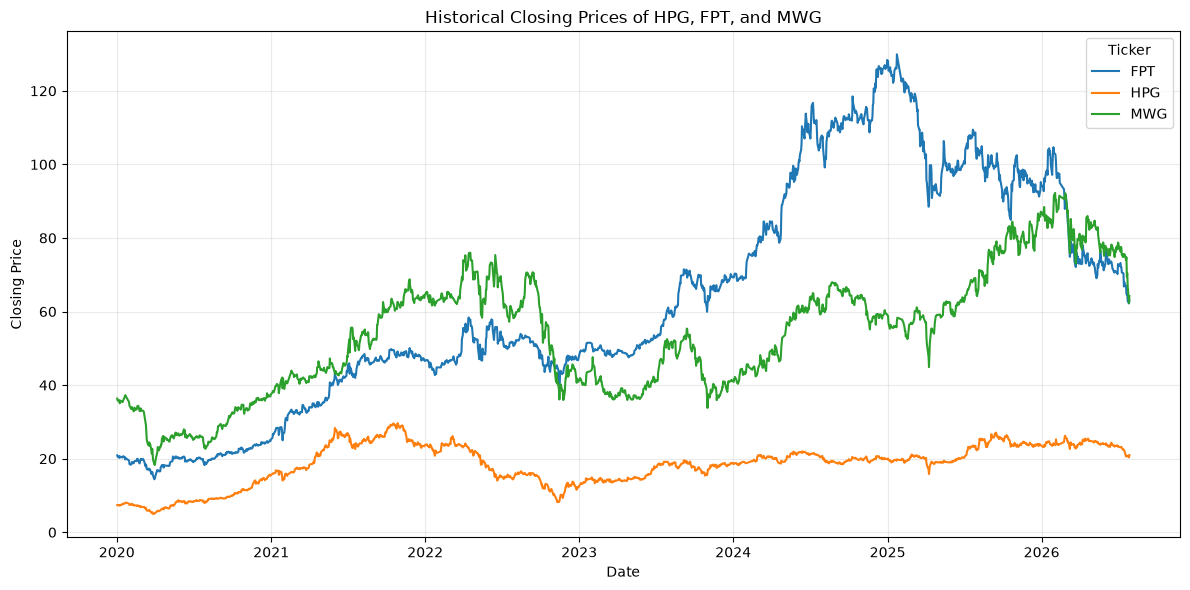

Figure saved to: c:\Users\Admin\Downloads\portfolio-var-risk-system\figures\eda\01_close_price_history.png


In [4]:
fig, ax = plt.subplots(
    figsize=(12, 6),
)

for ticker, group in market_data.groupby("ticker"):
    ax.plot(
        group["date"],
        group["close"],
        label=ticker,
        linewidth=1.5,
    )

ax.set_title(
    "Historical Closing Prices of HPG, FPT, and MWG"
)

ax.set_xlabel("Date")
ax.set_ylabel("Closing Price")

ax.legend(
    title="Ticker"
)

ax.grid(
    alpha=0.25,
)

fig.tight_layout()

figure_path = (
    FIGURE_DIR
    / "01_close_price_history.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Figure saved to: {figure_path}"
)

### Initial observations

- The three stocks exhibit different absolute price levels, so direct comparison of raw prices is not appropriate for measuring relative performance.
- All three series show time-varying trends and periods of stronger price fluctuations.
- A normalized price index is therefore required to compare cumulative price performance on a common scale.

## 3. Normalized Price Analysis

To compare the relative price performance of HPG, FPT, and MWG, each closing-price series is normalized to 100 at the beginning of the sample.

A normalized value above 100 indicates an increase relative to the initial closing price, while a value below 100 indicates a decline.

In [5]:
market_data["normalized_price"] = (
    market_data
    .groupby("ticker")["close"]
    .transform(
        lambda series: (
            series / series.iloc[0]
        ) * 100
    )
)


normalized_check = (
    market_data
    .groupby("ticker")
    .agg(
        first_close=("close", "first"),
        first_normalized=(
            "normalized_price",
            "first",
        ),
        last_close=("close", "last"),
        last_normalized=(
            "normalized_price",
            "last",
        ),
    )
)

normalized_check

,first_close,first_normalized,last_close,last_normalized
ticker,,,,
FPT,20.90,100.0,63.0,301.435407
HPG,7.38,100.0,21.0,284.552846
MWG,36.35,100.0,64.2,176.616231


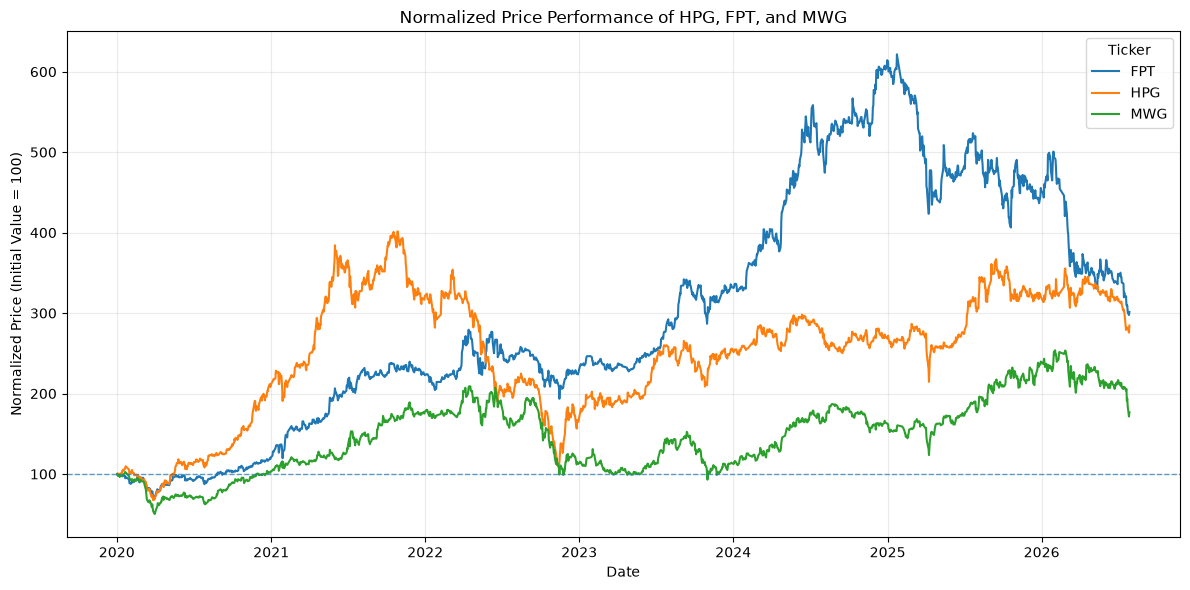

Figure saved to: c:\Users\Admin\Downloads\portfolio-var-risk-system\figures\eda\02_normalized_price.png


In [6]:
fig, ax = plt.subplots(
    figsize=(12, 6),
)

for ticker, group in market_data.groupby("ticker"):
    ax.plot(
        group["date"],
        group["normalized_price"],
        label=ticker,
        linewidth=1.5,
    )

ax.axhline(
    y=100,
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)

ax.set_title(
    "Normalized Price Performance of HPG, FPT, and MWG"
)

ax.set_xlabel("Date")
ax.set_ylabel(
    "Normalized Price (Initial Value = 100)"
)

ax.legend(
    title="Ticker"
)

ax.grid(
    alpha=0.25,
)

fig.tight_layout()

figure_path = (
    FIGURE_DIR
    / "02_normalized_price.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Figure saved to: {figure_path}"
)

In [7]:
performance_summary = (
    market_data
    .groupby("ticker")
    .agg(
        initial_close=("close", "first"),
        final_close=("close", "last"),
        final_normalized=(
            "normalized_price",
            "last",
        ),
    )
)

performance_summary["price_change_pct"] = (
    (
        performance_summary["final_close"]
        / performance_summary["initial_close"]
    )
    - 1
) * 100

performance_summary = (
    performance_summary
    .sort_values(
        "price_change_pct",
        ascending=False,
    )
)

performance_summary

,initial_close,final_close,final_normalized,price_change_pct
ticker,,,,
FPT,20.90,63.0,301.435407,201.435407
HPG,7.38,21.0,284.552846,184.552846
MWG,36.35,64.2,176.616231,76.616231


### Initial observations

- FPT recorded the strongest cumulative price appreciation over the sample period, increasing by approximately 201.44% from its initial closing price.
- HPG followed with an increase of approximately 184.55%, while MWG increased by approximately 76.62%.
- After normalization to a common base of 100, FPT ended the sample at approximately 301.44, HPG at 284.55, and MWG at 176.62.
- The normalized series confirms that differences in absolute stock prices should not be used to compare relative price performance.
- These results describe price appreciation over the sample period and should not be interpreted as total shareholder returns.

## 4. Log Return Analysis

Daily log returns are calculated from consecutive closing prices as:

\[
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
\]

Log returns are used in this notebook to examine short-term price changes and return distributions.

Because the calculation requires the previous trading day's closing price, the first observation of each ticker has an undefined log return and is retained as `NaN` at this stage.

In [8]:
market_data["previous_close"] = (
    market_data
    .groupby("ticker")["close"]
    .shift(1)
)

market_data["log_return"] = np.log(
    market_data["close"]
    / market_data["previous_close"]
)


return_check = (
    market_data
    .groupby("ticker")
    .agg(
        observations=("date", "size"),
        valid_returns=(
            "log_return",
            "count",
        ),
        missing_returns=(
            "log_return",
            lambda series: series.isna().sum(),
        ),
        first_return=(
            "log_return",
            "first",
        ),
    )
)

return_check

,observations,valid_returns,missing_returns,first_return
ticker,,,,
FPT,1638,1637,1,-0.017375
HPG,1638,1637,1,0.006752
MWG,1638,1637,1,-0.014688


In [9]:
market_data[
    [
        "date",
        "ticker",
        "close",
        "previous_close",
        "log_return",
    ]
].groupby(
    "ticker",
    group_keys=False,
).head(3)

,date,ticker,close,previous_close,log_return
0,2020-01-02,FPT,20.90,NaN,NaN
1,2020-01-03,FPT,20.54,20.90,-0.017375
2,2020-01-06,FPT,20.33,20.54,-0.010277
1638,2020-01-02,HPG,7.38,NaN,NaN
1639,2020-01-03,HPG,7.43,7.38,0.006752
1640,2020-01-06,HPG,7.38,7.43,-0.006752
3276,2020-01-02,MWG,36.35,NaN,NaN
3277,2020-01-03,MWG,35.82,36.35,-0.014688
3278,2020-01-06,MWG,35.64,35.82,-0.005038


In [10]:
return_quality = pd.DataFrame(
    {
        "missing": (
            market_data
            .groupby("ticker")["log_return"]
            .apply(lambda series: series.isna().sum())
        ),
        "positive_inf": (
            market_data
            .groupby("ticker")["log_return"]
            .apply(
                lambda series: np.isposinf(series).sum()
            )
        ),
        "negative_inf": (
            market_data
            .groupby("ticker")["log_return"]
            .apply(
                lambda series: np.isneginf(series).sum()
            )
        ),
    }
)

return_quality

,missing,positive_inf,negative_inf
ticker,,,
FPT,1,0,0
HPG,1,0,0
MWG,1,0,0


## 5. Daily Log Return Dynamics

Daily log returns are examined over time to identify changes in volatility, unusually large price movements, and potential volatility clustering.

Unlike price levels, returns are generally centered around zero and provide a more appropriate representation of short-term financial fluctuations.

In [11]:
returns_data = (
    market_data
    .dropna(subset=["log_return"])
    .copy()
)

print(
    f"Return observations: {len(returns_data)}"
)

print(
    returns_data
    .groupby("ticker")
    .size()
)

Return observations: 4911
ticker
FPT    1637
HPG    1637
MWG    1637
dtype: int64


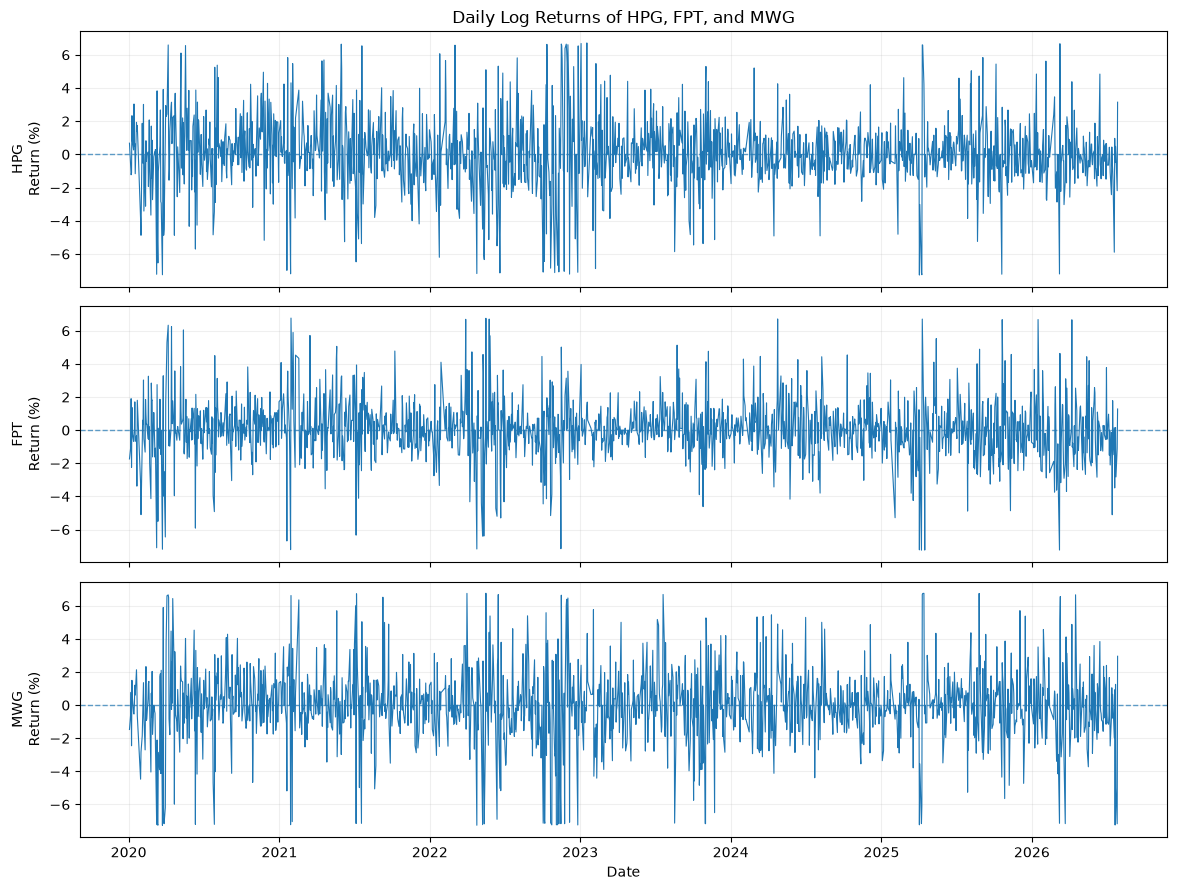

Figure saved to: c:\Users\Admin\Downloads\portfolio-var-risk-system\figures\eda\03_daily_returns.png


In [12]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 9),
    sharex=True,
)

for ax, ticker in zip(
    axes,
    TICKERS,
):
    ticker_data = returns_data[
        returns_data["ticker"] == ticker
    ]

    ax.plot(
        ticker_data["date"],
        ticker_data["log_return"] * 100,
        linewidth=0.8,
    )

    ax.axhline(
        y=0,
        linestyle="--",
        linewidth=1,
        alpha=0.7,
    )

    ax.set_ylabel(
        f"{ticker}\nReturn (%)"
    )

    ax.grid(
        alpha=0.2,
    )


axes[0].set_title(
    "Daily Log Returns of HPG, FPT, and MWG"
)

axes[-1].set_xlabel(
    "Date"
)

fig.tight_layout()

figure_path = (
    FIGURE_DIR
    / "03_daily_returns.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Figure saved to: {figure_path}"
)

### Initial observations

- Daily log returns fluctuate around zero, while their dispersion varies substantially over time.
- The return series exhibit visible volatility clustering, with periods of large movements followed by periods of relatively low volatility.
- Large negative and positive return observations are present for all three stocks and should not automatically be treated as data errors because they may represent genuine tail-risk events.
- Several extreme observations occur on the same trading dates across multiple stocks, suggesting the presence of market-wide stress episodes.
- The largest observed log returns are approximately -7.27% on the downside and +6.77% on the upside.

In [13]:
extreme_returns = (
    returns_data[
        [
            "date",
            "ticker",
            "log_return",
        ]
    ]
    .assign(
        abs_log_return=lambda frame: (
            frame["log_return"].abs()
        )
    )
    .sort_values(
        "abs_log_return",
        ascending=False,
    )
    .head(15)
    .copy()
)

extreme_returns["log_return_pct"] = (
    extreme_returns["log_return"] * 100
)

extreme_returns[
    [
        "date",
        "ticker",
        "log_return_pct",
    ]
]

,date,ticker,log_return_pct
2948,2025-04-03,HPG,-7.266623
3328,2020-03-23,MWG,-7.260207
3851,2022-04-25,MWG,-7.254741
3321,2020-03-12,MWG,-7.252319
1690,2020-03-23,HPG,-7.249550
2951,2025-04-09,HPG,-7.248225
1312,2025-04-08,FPT,-7.245994
4909,2026-07-22,MWG,-7.240094
1318,2025-04-16,FPT,-7.238465
1539,2026-03-09,FPT,-7.237968


In [14]:
return_range = (
    returns_data
    .groupby("ticker")
    .agg(
        min_log_return=(
            "log_return",
            "min",
        ),
        max_log_return=(
            "log_return",
            "max",
        ),
    )
)

return_range["min_return_pct"] = (
    return_range["min_log_return"] * 100
)

return_range["max_return_pct"] = (
    return_range["max_log_return"] * 100
)

return_range[
    [
        "min_return_pct",
        "max_return_pct",
    ]
]

,min_return_pct,max_return_pct
ticker,,
FPT,-7.245994,6.765865
HPG,-7.266623,6.713930
MWG,-7.260207,6.762019


## 6. Return Distribution

The distribution of daily log returns is examined to evaluate its center, dispersion, asymmetry, and tail behavior.

Particular attention is given to the lower tail because the 5th percentile of portfolio returns will later play a central role in the estimation of one-day 95% Value at Risk.

In [15]:
return_summary = (
    returns_data
    .groupby("ticker")["log_return"]
    .agg(
        observations="count",
        mean="mean",
        median="median",
        std="std",
        minimum="min",
        maximum="max",
        skewness="skew",
        kurtosis=lambda series: series.kurt(),
    )
)

return_summary

return_quantiles = (
    returns_data
    .groupby("ticker")["log_return"]
    .quantile(
        [0.01, 0.05, 0.95, 0.99]
    )
    .unstack()
    .rename(
        columns={
            0.01: "q01",
            0.05: "q05",
            0.95: "q95",
            0.99: "q99",
        }
    )
)

return_statistics = (
    return_summary
    .join(return_quantiles)
)

percentage_columns = [
    "mean",
    "median",
    "std",
    "minimum",
    "maximum",
    "q01",
    "q05",
    "q95",
    "q99",
]

return_statistics_display = (
    return_statistics.copy()
)

return_statistics_display[
    percentage_columns
] = (
    return_statistics_display[
        percentage_columns
    ]
    * 100
)

return_statistics_display.round(4)

,observations,mean,median,std,minimum,maximum,skewness,kurtosis,q01,q05,q95,q99
ticker,,,,,,,,,,,,
FPT,1637,0.0674,0.0,1.8190,-7.2460,6.7659,-0.0619,2.8545,-5.2955,-2.6561,3.1934,5.2359
HPG,1637,0.0639,0.0,2.1428,-7.2666,6.7139,-0.1173,2.0339,-6.9467,-3.3679,3.8468,6.3311
MWG,1637,0.0347,0.0,2.2556,-7.2602,6.7620,-0.3121,2.0758,-7.1645,-3.6333,3.7346,6.4940


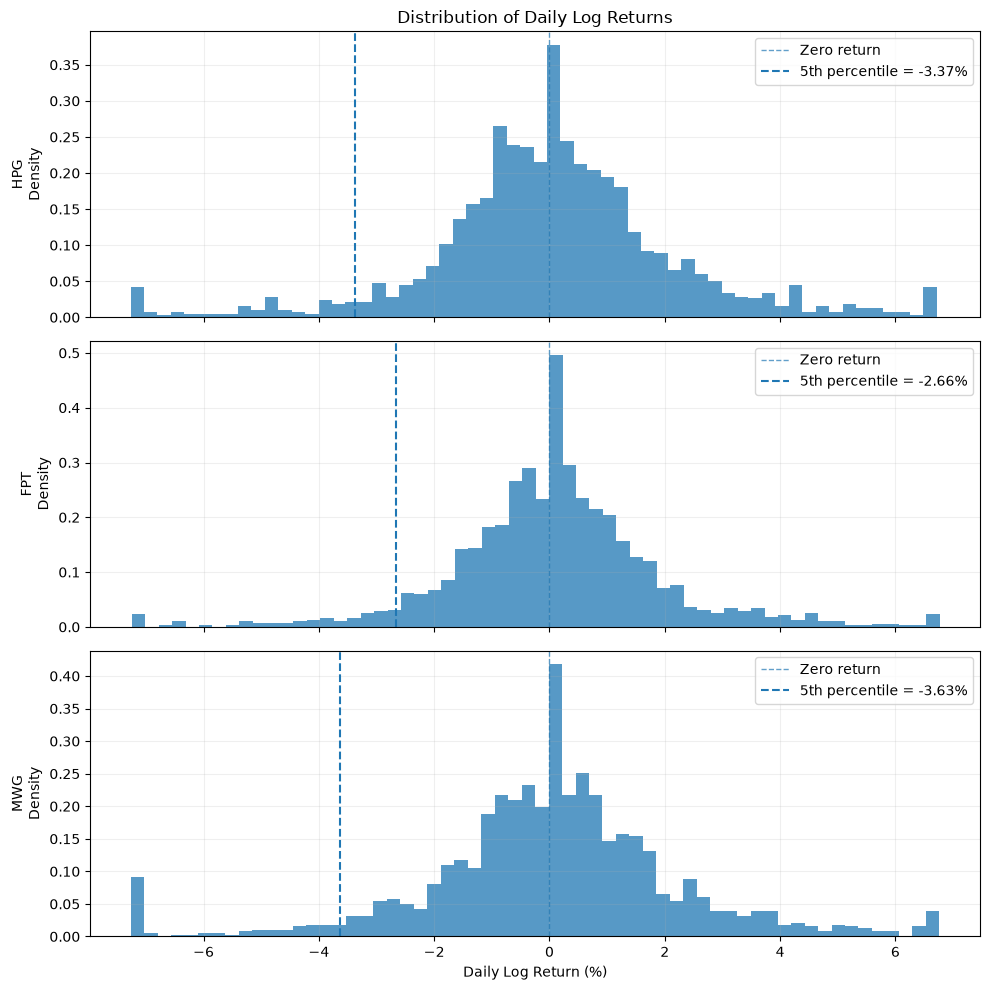

Figure saved to: c:\Users\Admin\Downloads\portfolio-var-risk-system\figures\eda\04_return_distribution.png


In [16]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(10, 10),
    sharex=True,
)

for ax, ticker in zip(
    axes,
    TICKERS,
):
    ticker_returns = (
        returns_data
        .loc[
            returns_data["ticker"] == ticker,
            "log_return",
        ]
        * 100
    )

    q05 = ticker_returns.quantile(0.05)

    ax.hist(
        ticker_returns,
        bins=60,
        density=True,
        alpha=0.75,
    )

    ax.axvline(
        x=0,
        linestyle="--",
        linewidth=1,
        alpha=0.7,
        label="Zero return",
    )

    ax.axvline(
        x=q05,
        linestyle="--",
        linewidth=1.5,
        label=f"5th percentile = {q05:.2f}%",
    )

    ax.set_ylabel(
        f"{ticker}\nDensity"
    )

    ax.legend()

    ax.grid(
        alpha=0.2,
    )


axes[0].set_title(
    "Distribution of Daily Log Returns"
)

axes[-1].set_xlabel(
    "Daily Log Return (%)"
)

fig.tight_layout()

figure_path = (
    FIGURE_DIR
    / "04_return_distribution.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Figure saved to: {figure_path}"
)

In [17]:
lower_tail_summary = (
    return_statistics[
        [
            "minimum",
            "q01",
            "q05",
            "mean",
            "std",
            "skewness",
            "kurtosis",
        ]
    ]
    .copy()
)

for column in [
    "minimum",
    "q01",
    "q05",
    "mean",
    "std",
]:
    lower_tail_summary[column] *= 100


lower_tail_summary.round(4)

,minimum,q01,q05,mean,std,skewness,kurtosis
ticker,,,,,,,
FPT,-7.2460,-5.2955,-2.6561,0.0674,1.8190,-0.0619,2.8545
HPG,-7.2666,-6.9467,-3.3679,0.0639,2.1428,-0.1173,2.0339
MWG,-7.2602,-7.1645,-3.6333,0.0347,2.2556,-0.3121,2.0758


### Distributional observations

- Daily log returns are centered close to zero for all three stocks, while their volatility differs substantially across securities.
- MWG exhibits the highest return volatility with a daily standard deviation of approximately 2.26%, followed by HPG at 2.14% and FPT at 1.82%.
- All three return distributions are negatively skewed, with MWG showing the strongest left-skewness. This indicates greater asymmetry toward negative return realizations.
- Positive excess kurtosis is observed for all three stocks, suggesting heavier tails than a Gaussian distribution and supporting the importance of explicitly examining tail risk.
- The empirical 5th percentiles are approximately -2.66% for FPT, -3.37% for HPG, and -3.63% for MWG. MWG therefore exhibits the deepest lower tail among the three individual stocks over the sample period.
- These individual-stock quantiles are exploratory statistics and should not be interpreted as the final portfolio VaR estimates.

In [18]:
zero_return_summary = (
    returns_data
    .assign(
        is_zero_return=lambda frame: (
            frame["log_return"].eq(0)
        )
    )
    .groupby("ticker")
    .agg(
        observations=(
            "log_return",
            "size",
        ),
        zero_return_days=(
            "is_zero_return",
            "sum",
        ),
    )
)

zero_return_summary["zero_return_pct"] = (
    zero_return_summary["zero_return_days"]
    / zero_return_summary["observations"]
    * 100
)

zero_return_summary

,observations,zero_return_days,zero_return_pct
ticker,,,
FPT,1637,89,5.436775
HPG,1637,94,5.742211
MWG,1637,95,5.803299


In [19]:
return_sign_summary = (
    returns_data
    .assign(
        return_sign=lambda frame: np.select(
            [
                frame["log_return"] < 0,
                frame["log_return"] > 0,
            ],
            [
                "negative",
                "positive",
            ],
            default="zero",
        )
    )
    .groupby(
        ["ticker", "return_sign"]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

return_sign_summary["total"] = (
    return_sign_summary.sum(axis=1)
)

for sign in [
    "negative",
    "zero",
    "positive",
]:
    return_sign_summary[
        f"{sign}_pct"
    ] = (
        return_sign_summary[sign]
        / return_sign_summary["total"]
        * 100
    )

return_sign_summary

return_sign,negative,positive,zero,total,negative_pct,zero_pct,positive_pct
ticker,,,,,,,
FPT,745,803,89,1637,45.510079,5.436775,49.053146
HPG,764,779,94,1637,46.670739,5.742211,47.587049
MWG,746,796,95,1637,45.571167,5.803299,48.625535


### Return sign distribution

Zero-return observations account for approximately 5.4%–5.8% of the daily return observations across the three stocks.

For each ticker, fewer than 50% of observations are negative, but the cumulative proportion of negative and zero returns exceeds 50%. Therefore, the median observation falls within the zero-return group, explaining why the empirical median log return is exactly zero for FPT, HPG, and MWG.

These zero-return observations are retained because they represent valid trading days with unchanged consecutive closing prices rather than missing or invalid data.

## 7. Outlier Analysis


**Outlier summary**


In [20]:
outlier_summary_rows = []
extreme_observations = {}

for ticker in TICKERS:
    ticker_returns = (
        returns_data
        .loc[
            returns_data["ticker"] == ticker,
            ["date", "ticker", "close", "log_return"],
        ]
        .copy()
    )

    q01 = ticker_returns["log_return"].quantile(0.01)
    q05 = ticker_returns["log_return"].quantile(0.05)
    q25 = ticker_returns["log_return"].quantile(0.25)
    q50 = ticker_returns["log_return"].quantile(0.50)
    q75 = ticker_returns["log_return"].quantile(0.75)
    q95 = ticker_returns["log_return"].quantile(0.95)
    q99 = ticker_returns["log_return"].quantile(0.99)

    iqr = q75 - q25
    lower_fence = q25 - 1.5 * iqr
    upper_fence = q75 + 1.5 * iqr

    outlier_mask = (
        ticker_returns["log_return"] < lower_fence
    ) | (
        ticker_returns["log_return"] > upper_fence
    )

    flagged_rows = (
        ticker_returns
        .loc[outlier_mask]
        .assign(
            return_pct=lambda frame: (
                frame["log_return"] * 100
            ),
            absolute_return=lambda frame: (
                frame["log_return"].abs()
            ),
        )
        .sort_values(
            "absolute_return",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    extreme_observations[ticker] = flagged_rows

    minimum_index = (
        ticker_returns["log_return"].idxmin()
    )

    maximum_index = (
        ticker_returns["log_return"].idxmax()
    )

    outlier_summary_rows.append(
        {
            "ticker": ticker,
            "observations": len(ticker_returns),
            "minimum_return": ticker_returns.loc[
                minimum_index,
                "log_return",
            ],
            "minimum_date": ticker_returns.loc[
                minimum_index,
                "date",
            ],
            "maximum_return": ticker_returns.loc[
                maximum_index,
                "log_return",
            ],
            "maximum_date": ticker_returns.loc[
                maximum_index,
                "date",
            ],
            "q01": q01,
            "q05": q05,
            "q25": q25,
            "median": q50,
            "q75": q75,
            "q95": q95,
            "q99": q99,
            "iqr": iqr,
            "lower_fence": lower_fence,
            "upper_fence": upper_fence,
            "iqr_outlier_rows": int(
                outlier_mask.sum()
            ),
        }
    )


outlier_summary = pd.DataFrame(
    outlier_summary_rows
)

outlier_summary


,ticker,observations,minimum_return,minimum_date,maximum_return,maximum_date,q01,q05,q25,median,q75,q95,q99,iqr,lower_fence,upper_fence,iqr_outlier_rows
0,HPG,1637,-0.072666,2025-04-03,0.067139,2023-01-17,-0.069467,-0.033679,-0.009504,0.0,0.011022,0.038468,0.063311,0.020527,-0.040294,0.041812,128
1,FPT,1637,-0.072460,2025-04-08,0.067659,2021-01-29,-0.052955,-0.026561,-0.008058,0.0,0.009375,0.031934,0.052359,0.017433,-0.034208,0.035525,116
2,MWG,1637,-0.072602,2020-03-23,0.067620,2022-05-17,-0.071645,-0.036333,-0.009919,0.0,0.011626,0.037346,0.064940,0.021545,-0.042237,0.043944,120


**Percentage view**


In [21]:
outlier_summary_display = outlier_summary.copy()

percentage_columns = [
    "minimum_return",
    "maximum_return",
    "q01",
    "q05",
    "q25",
    "median",
    "q75",
    "q95",
    "q99",
    "iqr",
    "lower_fence",
    "upper_fence",
]

outlier_summary_display[
    percentage_columns
] = (
    outlier_summary_display[
        percentage_columns
    ] * 100
)

outlier_summary_display.round(4)


,ticker,observations,minimum_return,minimum_date,maximum_return,maximum_date,q01,q05,q25,median,q75,q95,q99,iqr,lower_fence,upper_fence,iqr_outlier_rows
0,HPG,1637,-7.2666,2025-04-03,6.7139,2023-01-17,-6.9467,-3.3679,-0.9504,0.0,1.1022,3.8468,6.3311,2.0527,-4.0294,4.1812,128
1,FPT,1637,-7.2460,2025-04-08,6.7659,2021-01-29,-5.2955,-2.6561,-0.8058,0.0,0.9375,3.1934,5.2359,1.7433,-3.4208,3.5525,116
2,MWG,1637,-7.2602,2020-03-23,6.7620,2022-05-17,-7.1645,-3.6333,-0.9919,0.0,1.1626,3.7346,6.4940,2.1545,-4.2237,4.3944,120


**Largest return movements**


In [22]:
top_extreme_observations = (
    returns_data[
        [
            "date",
            "ticker",
            "close",
            "log_return",
        ]
    ]
    .assign(
        absolute_return=lambda frame: (
            frame["log_return"].abs()
        ),
        return_pct=lambda frame: (
            frame["log_return"] * 100
        ),
    )
    .sort_values(
        "absolute_return",
        ascending=False,
    )
    .head(20)
)

top_extreme_observations[
    [
        "date",
        "ticker",
        "close",
        "return_pct",
    ]
]


,date,ticker,close,return_pct
2948,2025-04-03,HPG,18.84,-7.266623
3328,2020-03-23,MWG,22.31,-7.260207
3851,2022-04-25,MWG,68.71,-7.254741
3321,2020-03-12,MWG,25.26,-7.252319
1690,2020-03-23,HPG,5.32,-7.249550
2951,2025-04-09,HPG,15.83,-7.248225
1312,2025-04-08,FPT,88.49,-7.245994
4909,2026-07-22,MWG,69.52,-7.240094
1318,2025-04-16,FPT,90.85,-7.238465
1539,2026-03-09,FPT,74.87,-7.237968


**Ticker-level outlier review**


In [23]:
for ticker in TICKERS:
    print(
        f"\n{ticker}: "
        f"{len(extreme_observations[ticker])} "
        "quan sát vượt ngưỡng IQR"
    )

    display(
        extreme_observations[ticker][
            [
                "date",
                "close",
                "return_pct",
            ]
        ].head(15)
    )



HPG: 128 quan sát vượt ngưỡng IQR


,date,close,return_pct
0,2025-04-03,18.84,-7.266623
1,2020-03-23,5.32,-7.249550
2,2025-04-09,15.83,-7.248225
3,2020-03-09,6.41,-7.221181
4,2025-10-20,23.25,-7.217061
5,2022-12-06,12.57,-7.211713
6,2026-03-09,22.63,-7.202260
7,2021-01-28,14.08,-7.192418
8,2022-04-25,20.83,-7.177345
9,2025-04-08,17.02,-7.141844



FPT: 116 quan sát vượt ngưỡng IQR


,date,close,return_pct
0,2025-04-08,88.49,-7.245994
1,2025-04-16,90.85,-7.238465
2,2026-03-09,74.87,-7.237968
3,2025-04-03,95.56,-7.225252
4,2021-01-28,25.00,-7.213460
5,2020-03-23,15.83,-7.189453
6,2022-04-25,51.77,-7.173202
7,2022-11-15,40.44,-7.156128
8,2020-03-09,17.94,-7.099755
9,2021-01-29,26.75,6.765865



MWG: 120 quan sát vượt ngưỡng IQR


,date,close,return_pct
0,2020-03-23,22.31,-7.260207
1,2022-04-25,68.71,-7.254741
2,2020-03-12,25.26,-7.252319
3,2026-07-22,69.52,-7.240094
4,2022-12-26,40.64,-7.236644
5,2022-10-24,48.27,-7.231584
6,2025-04-03,53.10,-7.227686
7,2022-11-04,43.93,-7.222007
8,2021-01-28,39.13,-7.220773
9,2022-11-07,40.87,-7.220116


**Return boxplot**


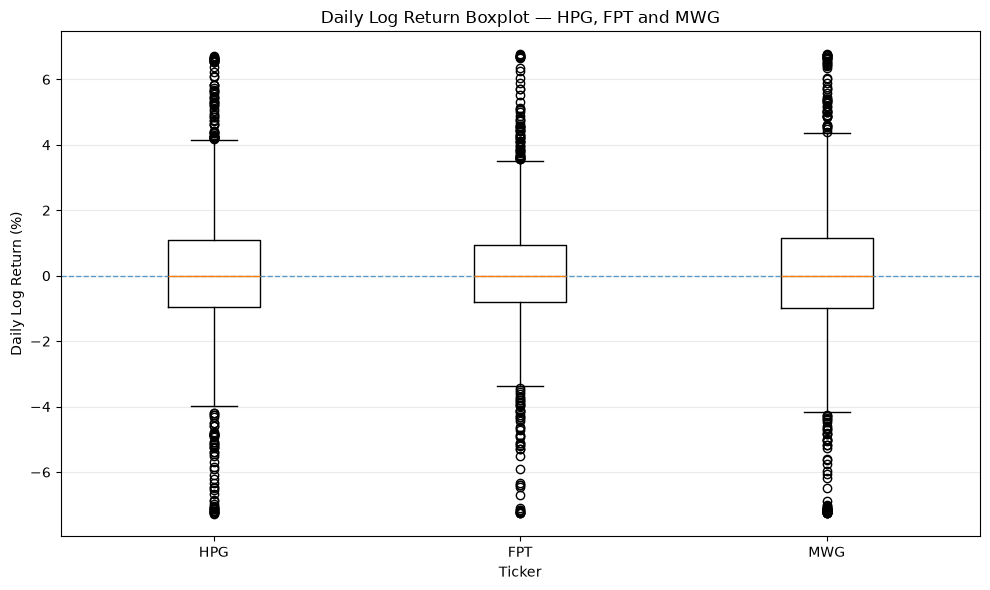

Đã lưu: c:\Users\Admin\Downloads\portfolio-var-risk-system\figures\eda\05_return_boxplot.png


In [24]:
fig, ax = plt.subplots(
    figsize=(10, 6),
)

boxplot_values = [
    (
        returns_data
        .loc[
            returns_data["ticker"] == ticker,
            "log_return",
        ]
        .dropna()
        .to_numpy()
        * 100
    )
    for ticker in TICKERS
]

ax.boxplot(
    boxplot_values,
    tick_labels=TICKERS,
    showfliers=True,
)

ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)

ax.set_title(
    "Daily Log Return Boxplot — HPG, FPT and MWG"
)

ax.set_xlabel("Ticker")
ax.set_ylabel("Daily Log Return (%)")
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()

boxplot_path = (
    FIGURE_DIR / "05_return_boxplot.png"
)

fig.savefig(
    boxplot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Đã lưu:", boxplot_path)


### Outlier observations

- HPG recorded the most negative daily log return in the sample,
  approximately **-7.2666% on 2025-04-03**.
- FPT recorded the largest positive daily log return,
  approximately **6.7659% on 2021-01-29**.
- The IQR rule flagged **128 HPG**, **116 FPT**, and **120 MWG**
  observations as unusually large return movements.
- These observations are retained rather than automatically removed
  because extreme market movements are economically meaningful for
  downstream risk analysis.


## 8. Correlation Analysis


In [25]:
return_matrix = (
    returns_data
    .pivot(
        index="date",
        columns="ticker",
        values="log_return",
    )
    .sort_index()
    .reindex(columns=TICKERS)
)

return_matrix.head()


ticker,HPG,FPT,MWG
date,,,
2020-01-03,0.006752,-0.017375,-0.014688
2020-01-06,-0.006752,-0.010277,-0.005038
2020-01-07,-0.012270,0.019002,0.007826
2020-01-08,-0.011035,-0.022451,-0.024519
2020-01-09,0.023305,0.013726,0.015008


**Correlation matrix**


In [26]:
aligned_returns = (
    return_matrix[TICKERS]
    .dropna(how="any")
)

correlation_matrix = aligned_returns.corr()

print(
    "Số ngày được dùng để tính correlation:",
    len(aligned_returns),
)

correlation_matrix.round(4)


Số ngày được dùng để tính correlation: 1637


ticker,HPG,FPT,MWG
ticker,,,
HPG,1.0000,0.4926,0.5198
FPT,0.4926,1.0000,0.5423
MWG,0.5198,0.5423,1.0000


**Strongest and weakest correlation pairs**


In [27]:
upper_triangle_mask = np.triu(
    np.ones(
        correlation_matrix.shape,
        dtype=bool,
    ),
    k=1,
)

correlation_pairs = (
    correlation_matrix
    .where(upper_triangle_mask)
    .stack()
    .sort_values(ascending=False)
)

highest_pair = correlation_pairs.index[0]
highest_value = correlation_pairs.iloc[0]

lowest_pair = correlation_pairs.index[-1]
lowest_value = correlation_pairs.iloc[-1]

print(
    "Cặp tương quan cao nhất:",
    f"{highest_pair[0]} - {highest_pair[1]}",
    f"= {highest_value:.4f}",
)

print(
    "Cặp tương quan thấp nhất:",
    f"{lowest_pair[0]} - {lowest_pair[1]}",
    f"= {lowest_value:.4f}",
)


Cặp tương quan cao nhất: FPT - MWG = 0.5423
Cặp tương quan thấp nhất: HPG - FPT = 0.4926


**Correlation heatmap**


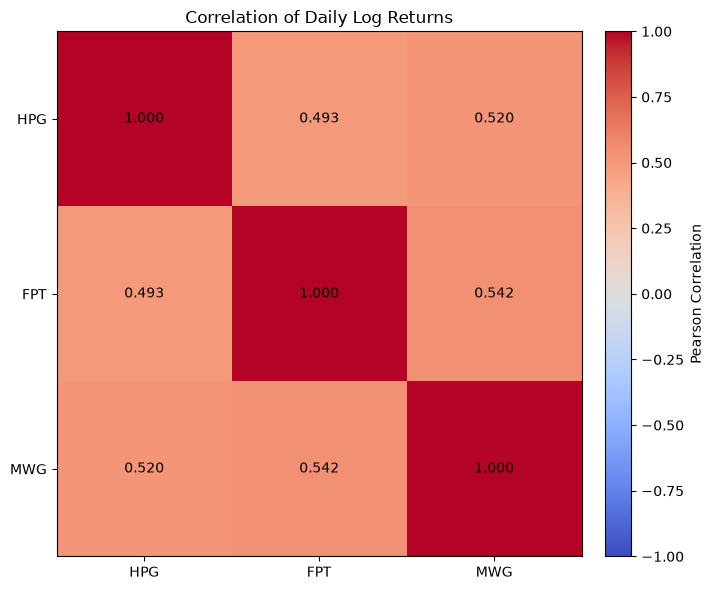

Đã lưu: c:\Users\Admin\Downloads\portfolio-var-risk-system\figures\eda\06_return_correlation.png


In [28]:
fig, ax = plt.subplots(
    figsize=(7, 6),
)

image = ax.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)

ax.set_xticks(
    range(len(TICKERS)),
    labels=TICKERS,
)

ax.set_yticks(
    range(len(TICKERS)),
    labels=TICKERS,
)

for row in range(len(TICKERS)):
    for column in range(len(TICKERS)):
        value = correlation_matrix.iloc[
            row,
            column,
        ]

        ax.text(
            column,
            row,
            f"{value:.3f}",
            ha="center",
            va="center",
        )

ax.set_title(
    "Correlation of Daily Log Returns"
)

colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04,
)

colorbar.set_label(
    "Pearson Correlation"
)

fig.tight_layout()

correlation_path = (
    FIGURE_DIR / "06_return_correlation.png"
)

fig.savefig(
    correlation_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Đã lưu:", correlation_path)


### Correlation observations

- Daily log returns exhibit positive cross-asset dependence.
- The highest pairwise correlation is **FPT?MWG (0.5423)**.
- The lowest pairwise correlation is **HPG?FPT (0.4926)**.
- The relatively lower HPG?FPT correlation suggests stronger
  preliminary diversification potential than the other observed
  pairs, but this EDA does not perform portfolio optimization.


## 9. Rolling Volatility Analysis


**Rolling-volatility calculation**


In [29]:
market_data["rolling_vol_20"] = (
    market_data
    .groupby("ticker")["log_return"]
    .transform(
        lambda series: (
            series
            .rolling(
                window=20,
                min_periods=20,
            )
            .std()
        )
    )
)

rolling_volatility_check = (
    market_data
    .groupby("ticker")
    .agg(
        valid_rolling_volatility=(
            "rolling_vol_20",
            "count",
        ),
        missing_rolling_volatility=(
            "rolling_vol_20",
            lambda series: series.isna().sum(),
        ),
    )
)

rolling_volatility_check


,valid_rolling_volatility,missing_rolling_volatility
ticker,,
FPT,1618,20
HPG,1618,20
MWG,1618,20


**Rolling-volatility summary**


In [30]:
rolling_summary_rows = []

for ticker in TICKERS:
    ticker_data = (
        market_data
        .loc[
            market_data["ticker"] == ticker,
            ["date", "rolling_vol_20"],
        ]
        .dropna()
        .copy()
    )

    maximum_index = (
        ticker_data["rolling_vol_20"].idxmax()
    )

    rolling_summary_rows.append(
        {
            "ticker": ticker,
            "mean_rolling_vol_20": (
                ticker_data["rolling_vol_20"].mean()
            ),
            "median_rolling_vol_20": (
                ticker_data["rolling_vol_20"].median()
            ),
            "maximum_rolling_vol_20": (
                ticker_data.loc[
                    maximum_index,
                    "rolling_vol_20",
                ]
            ),
            "maximum_volatility_date": (
                ticker_data.loc[
                    maximum_index,
                    "date",
                ]
            ),
        }
    )


rolling_volatility_summary = pd.DataFrame(
    rolling_summary_rows
)

rolling_volatility_display = (
    rolling_volatility_summary.copy()
)

for column in [
    "mean_rolling_vol_20",
    "median_rolling_vol_20",
    "maximum_rolling_vol_20",
]:
    rolling_volatility_display[column] *= 100

rolling_volatility_display.round(4)


,ticker,mean_rolling_vol_20,median_rolling_vol_20,maximum_rolling_vol_20,maximum_volatility_date
0,HPG,1.9681,1.7981,4.9695,2022-12-02
1,FPT,1.6808,1.5998,3.9428,2020-04-06
2,MWG,2.0818,1.8596,5.2318,2020-04-07


**Rolling-volatility chart**


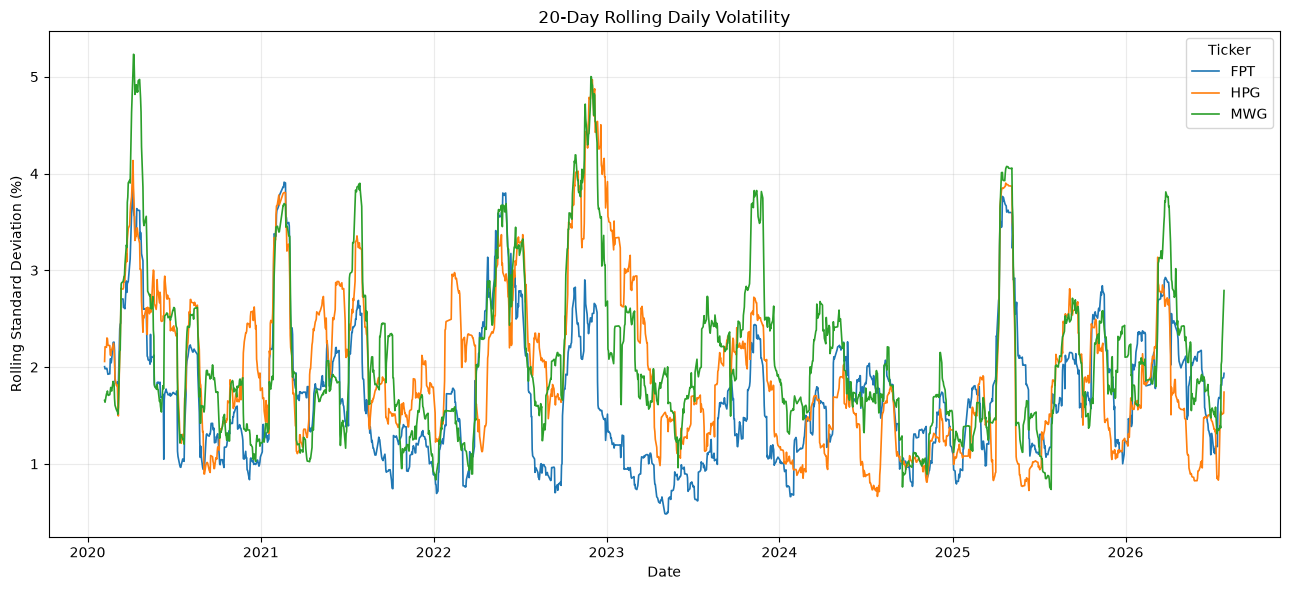

Đã lưu: c:\Users\Admin\Downloads\portfolio-var-risk-system\figures\eda\07_rolling_volatility_20d.png


In [31]:
fig, ax = plt.subplots(
    figsize=(13, 6),
)

for ticker, group in market_data.groupby("ticker"):
    ax.plot(
        group["date"],
        group["rolling_vol_20"] * 100,
        label=ticker,
        linewidth=1.2,
    )

ax.set_title(
    "20-Day Rolling Daily Volatility"
)

ax.set_xlabel("Date")
ax.set_ylabel(
    "Rolling Standard Deviation (%)"
)

ax.legend(title="Ticker")
ax.grid(alpha=0.25)

fig.tight_layout()

rolling_path = (
    FIGURE_DIR
    / "07_rolling_volatility_20d.png"
)

fig.savefig(
    rolling_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Đã lưu:", rolling_path)


### Rolling-volatility observations

- MWG has the highest average 20-session rolling volatility,
  approximately **2.0818%**.
- MWG also records the highest observed rolling-volatility peak,
  approximately **5.2318%**.
- The maximum rolling-volatility observation occurs on
  **2020-04-07**.
- The time-series behavior displays volatility clustering:
  high-volatility and low-volatility periods tend to occur in
  persistent regimes rather than independently from day to day.


## 10. Tail Risk Analysis


**Tail statistics**


In [32]:
tail_statistics = (
    returns_data
    .groupby("ticker")["log_return"]
    .agg(
        observations="count",
        mean="mean",
        standard_deviation="std",
        skewness="skew",
        kurtosis=lambda series: series.kurt(),
    )
)

tail_quantiles = (
    returns_data
    .groupby("ticker")["log_return"]
    .quantile(
        [0.01, 0.05, 0.95, 0.99]
    )
    .unstack()
    .rename(
        columns={
            0.01: "return_q01",
            0.05: "return_q05",
            0.95: "return_q95",
            0.99: "return_q99",
        }
    )
)

tail_statistics = (
    tail_statistics
    .join(tail_quantiles)
)

tail_statistics


,observations,mean,standard_deviation,skewness,kurtosis,return_q01,return_q05,return_q95,return_q99
ticker,,,,,,,,,
FPT,1637,0.000674,0.018190,-0.061923,2.854547,-0.052955,-0.026561,0.031934,0.052359
HPG,1637,0.000639,0.021428,-0.117284,2.033945,-0.069467,-0.033679,0.038468,0.063311
MWG,1637,0.000347,0.022556,-0.312142,2.075760,-0.071645,-0.036333,0.037346,0.064940


**Percentage view**


In [33]:
tail_statistics_display = (
    tail_statistics.copy()
)

percentage_columns = [
    "mean",
    "standard_deviation",
    "return_q01",
    "return_q05",
    "return_q95",
    "return_q99",
]

tail_statistics_display[
    percentage_columns
] = (
    tail_statistics_display[
        percentage_columns
    ] * 100
)

tail_statistics_display.round(4)


,observations,mean,standard_deviation,skewness,kurtosis,return_q01,return_q05,return_q95,return_q99
ticker,,,,,,,,,
FPT,1637,0.0674,1.8190,-0.0619,2.8545,-5.2955,-2.6561,3.1934,5.2359
HPG,1637,0.0639,2.1428,-0.1173,2.0339,-6.9467,-3.3679,3.8468,6.3311
MWG,1637,0.0347,2.2556,-0.3121,2.0758,-7.1645,-3.6333,3.7346,6.4940


**Observations in the 5% left tail**


In [34]:
left_tail_rows = []

for ticker in TICKERS:
    ticker_returns = (
        returns_data
        .loc[
            returns_data["ticker"] == ticker,
            ["date", "ticker", "log_return"],
        ]
        .copy()
    )

    q05 = ticker_returns[
        "log_return"
    ].quantile(0.05)

    ticker_left_tail = (
        ticker_returns
        .loc[
            ticker_returns["log_return"] <= q05
        ]
        .assign(
            return_pct=lambda frame: (
                frame["log_return"] * 100
            )
        )
        .sort_values("log_return")
    )

    left_tail_rows.append(ticker_left_tail)


left_tail_observations = pd.concat(
    left_tail_rows,
    ignore_index=True,
)

left_tail_summary = (
    left_tail_observations
    .groupby("ticker")
    .agg(
        left_tail_rows=("date", "size"),
        earliest_tail_date=("date", "min"),
        latest_tail_date=("date", "max"),
        worst_tail_return_pct=(
            "return_pct",
            "min",
        ),
    )
)

left_tail_summary.round(4)


,left_tail_rows,earliest_tail_date,latest_tail_date,worst_tail_return_pct
ticker,,,,
FPT,82,2020-01-21,2026-07-24,-7.2460
HPG,82,2020-01-30,2026-07-20,-7.2666
MWG,82,2020-01-30,2026-07-27,-7.2602


**Left-tail visualization**


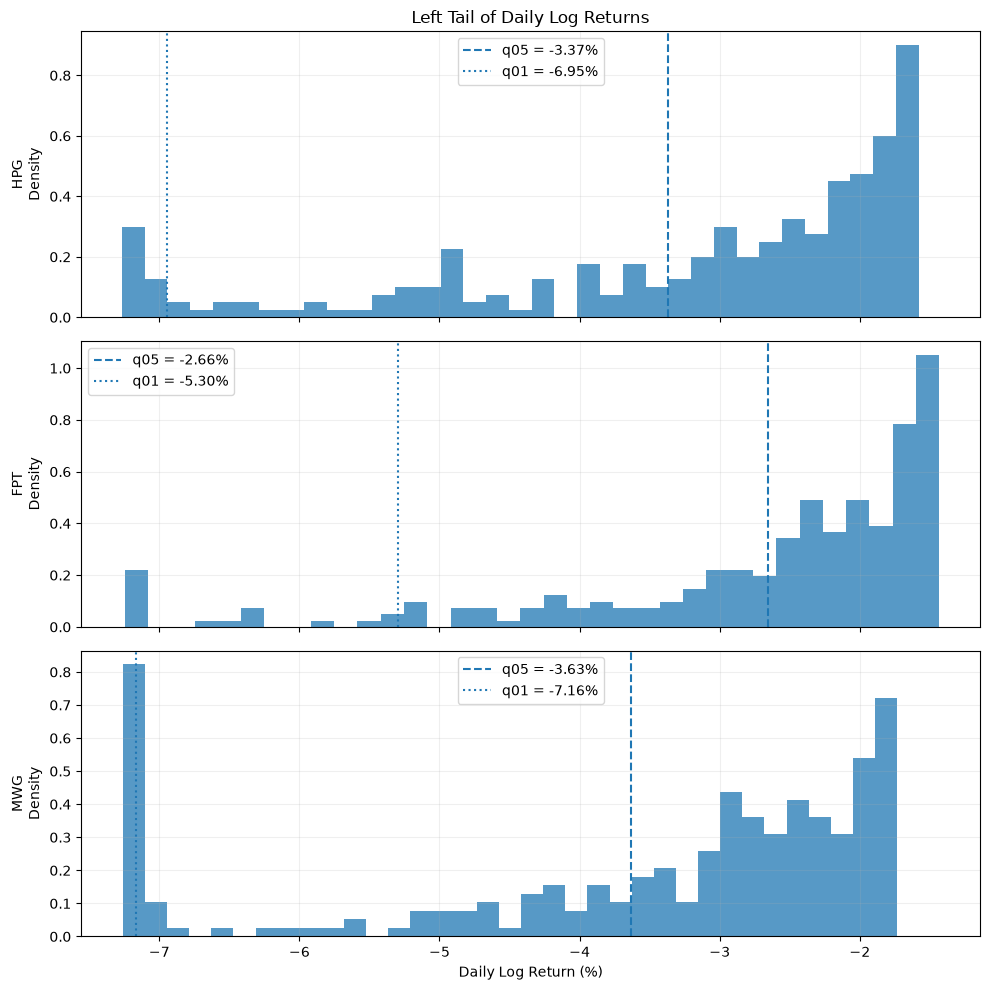

Đã lưu: c:\Users\Admin\Downloads\portfolio-var-risk-system\figures\eda\08_left_tail_returns.png


In [35]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(10, 10),
    sharex=True,
)

for ax, ticker in zip(
    axes,
    TICKERS,
):
    ticker_returns = (
        returns_data
        .loc[
            returns_data["ticker"] == ticker,
            "log_return",
        ]
        .dropna()
        * 100
    )

    q01 = ticker_returns.quantile(0.01)
    q05 = ticker_returns.quantile(0.05)

    left_plot_limit = (
        ticker_returns.quantile(0.15)
    )

    plotted_returns = ticker_returns[
        ticker_returns <= left_plot_limit
    ]

    ax.hist(
        plotted_returns,
        bins=35,
        density=True,
        alpha=0.75,
    )

    ax.axvline(
        q05,
        linestyle="--",
        linewidth=1.5,
        label=f"q05 = {q05:.2f}%",
    )

    ax.axvline(
        q01,
        linestyle=":",
        linewidth=1.5,
        label=f"q01 = {q01:.2f}%",
    )

    ax.set_ylabel(
        f"{ticker}\nDensity"
    )

    ax.legend()
    ax.grid(alpha=0.2)


axes[0].set_title(
    "Left Tail of Daily Log Returns"
)

axes[-1].set_xlabel(
    "Daily Log Return (%)"
)

fig.tight_layout()

left_tail_path = (
    FIGURE_DIR
    / "08_left_tail_returns.png"
)

fig.savefig(
    left_tail_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Đã lưu:", left_tail_path)


### Tail-risk observations

- MWG has the most negative 5th-percentile log return,
  approximately **-3.6333%**, indicating the deepest q05 left tail
  among the three stocks.
- The most negative single observed log return belongs to HPG at
  approximately **-7.2666%**.
- All three return distributions exhibit negative skewness:
  FPT **-0.0619**, HPG **-0.1173**, and MWG **-0.3121**.
- All three series have positive excess kurtosis:
  FPT **2.8545**, HPG **2.0339**, and MWG **2.0758**,
  indicating heavier tails than a Gaussian benchmark.
- Individual-stock q05 values are exploratory downside-tail
  diagnostics only. They are **not** the final portfolio VaR.


## 11. Key Findings

### Return behavior

- Daily stock returns are centered close to zero, while the three
  series exhibit materially different volatility levels.
- MWG shows the highest overall return variability among the three
  stocks, followed by HPG and FPT.
- Extreme return observations are retained because they contain
  information relevant to market-risk analysis.

### Cross-asset dependence

- Pairwise return correlations are positive and moderate.
- FPT?MWG has the highest observed correlation (**0.5423**), while
  HPG?FPT has the lowest (**0.4926**).
- The correlation structure indicates some diversification potential,
  but common market shocks can still affect all portfolio components
  simultaneously.

### Volatility dynamics

- The 20-session rolling-volatility analysis shows clear volatility
  clustering.
- MWG has the highest average rolling volatility (**2.0818%**) and
  the highest observed rolling-volatility peak (**5.2318%**).
- The maximum observed rolling-volatility date is **2020-04-07**.

### Tail behavior

- All three return distributions have negative skewness and positive
  excess kurtosis, supporting the presence of asymmetric and
  heavy-tailed return behavior.
- MWG has the deepest 5th-percentile left tail at approximately
  **-3.6333%**.
- HPG records the most negative single daily log return at
  approximately **-7.2666%**.
- Individual-stock q05 estimates are descriptive tail diagnostics
  only and must not be interpreted as the final portfolio VaR.

### Scope

- No extreme-return observations are automatically removed.
- No portfolio optimization is performed in this notebook.
- No VaR forecast is produced in this notebook.
- The EDA provides validated descriptive evidence and inputs for the
  subsequent portfolio-risk modeling pipeline.
